# BNPL Fraud Detection — ML Models & SHAP Explanations

Given a new BNPL order, should we approve it, flag it for review, or block it? The cost asymmetry is extreme: a missed fraud case costs ~$500 in chargebacks, while a false block costs ~$50 in lost revenue and customer friction.

This notebook trains four classifiers on the BNPL fraud-detection feature matrix, evaluates them with a time-based train/test split, and provides SHAP explanations for the best performer.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, roc_auc_score,
    roc_curve, confusion_matrix, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import joblib

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("⚠ xgboost not installed — XGBoost model will be skipped.")

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("⚠ lightgbm not installed — LightGBM model will be skipped.")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("⚠ shap not installed — SHAP explanation sections will be skipped.")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

RANDOM_STATE = 42
DATA_DIR = Path("../data")

In [2]:
def load_feature_matrix():
    parquet_path = DATA_DIR / "feature_matrix.parquet"
    csv_path = DATA_DIR / "feature_matrix.csv"

    if parquet_path.exists():
        try:
            df = pd.read_parquet(parquet_path)
            print(f"Loaded feature matrix from {parquet_path} — {df.shape}")
            return df
        except Exception:
            pass

    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(f"Loaded feature matrix from {csv_path} — {df.shape}")
        return df

    print("Feature matrix files not found — building from bnpl.db …")
    return build_features_from_db()


def build_features_from_db():
    import sqlite3
    conn = sqlite3.connect(str(DATA_DIR / "bnpl.db"))

    orders = pd.read_sql("SELECT * FROM orders", conn)
    plans = pd.read_sql("SELECT * FROM payment_plans", conn)
    installments = pd.read_sql("SELECT * FROM installments", conn)
    devices = pd.read_sql("SELECT * FROM device_fingerprints", conn)
    segments = pd.read_sql("SELECT * FROM customer_segments_ground_truth", conn)
    conn.close()

    orders["order_amount"] = (
        orders["order_amount"]
        .astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .astype(float)
        .abs()
        .clip(upper=10_000)
    )
    orders["log_amount"] = np.log1p(orders["order_amount"])
    orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")

    df = orders.merge(plans, on="order_id", how="left")

    inst_agg = (
        installments.groupby("plan_id")
        .agg(
            days_past_due_mean=("days_past_due", "mean"),
            days_past_due_max=("days_past_due", "max"),
            late_installments=("days_past_due", lambda x: (x > 0).sum()),
        )
        .reset_index()
    )
    df = df.merge(inst_agg, on="plan_id", how="left")

    dev_agg = (
        devices.groupby("order_id")
        .agg(is_vpn=("is_vpn", "max"))
        .reset_index()
    )
    df = df.merge(dev_agg, on="order_id", how="left")

    prior_orders = (
        orders.sort_values("order_date")
        .groupby("customer_id")
        .cumcount()
        .rename("num_prior_orders")
    )
    df["num_prior_orders"] = prior_orders.values

    if "plan_type" in df.columns:
        le = LabelEncoder()
        df["plan_type_encoded"] = le.fit_transform(df["plan_type"].fillna("unknown"))

    if "channel" in df.columns:
        le2 = LabelEncoder()
        df["channel_encoded"] = le2.fit_transform(df["channel"].fillna("unknown"))

    fraud_labels = pd.read_sql("SELECT order_id, is_fraud FROM order_fraud_labels",
                               sqlite3.connect(str(DATA_DIR / "bnpl.db")))
    df = df.merge(fraud_labels, on="order_id", how="left")
    df["is_fraud"] = df["is_fraud"].fillna(0).astype(int)

    print(f"Built feature matrix from DB — {df.shape}")
    return df


df = load_feature_matrix()

Loaded feature matrix from ../data/feature_matrix.parquet — (155750, 76)


In [3]:
fraud_rate = df["is_fraud"].mean()
print(f"Shape: {df.shape}")
print(f"Fraud rate: {fraud_rate:.2%} ({df['is_fraud'].sum()} / {len(df)})")
print(f"\nFeatures ({df.shape[1]} columns):")
print(df.dtypes.to_string())

Shape: (155750, 76)
Fraud rate: 6.07% (9453 / 155750)

Features (76 columns):
order_id                        int64
customer_id                     int64
merchant_id                     int64
order_amount                  float64
order_seq                       int64
is_fraud                        int64
total_installments_before     float64
missed_installments_before    float64
late_installments_before      float64
paid_installments_before      float64
mean_dpd_before               float64
ontime_rate                   float64
missed_rate                   float64
is_fpd                        float64
cum_fpd_count                 float64
days_since_last_order         float64
log_order_amount              float64
cum_order_amount              float64
avg_prev_amount               float64
amount_vs_avg                 float64
orders_7d                       int64
spend_7d                      float64
orders_14d                      int64
spend_14d                     float64
orders_30d

## Data Preparation

**Why a time-based split?** In production, a fraud model only ever scores *future* orders.
A random split lets future information leak into training (e.g., new fraud patterns,
merchant behaviour shifts) and inflates metrics. A temporal split faithfully simulates
deployment: the model trains on older data and is evaluated on newer, unseen data.

In [4]:
ID_AND_DATE_COLS = [
    "order_id", "customer_id", "merchant_id", "plan_id",
    "fingerprint_id", "installment_id", "device_id",
    "order_date", "start_date", "end_date", "due_date",
    "ip_address", "browser", "os", "device_type",
    "order_status", "plan_status", "status", "segment",
    "plan_type", "channel",
]

date_col = None
for col in ["order_date", "start_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        if df[col].notna().any():
            date_col = col
            break

if date_col:
    df = df.sort_values(date_col).reset_index(drop=True)
else:
    print("No date column found — using row order as proxy for time.")

split_idx = int(len(df) * 0.75)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Train: {len(train_df):,} rows  |  Fraud rate: {train_df['is_fraud'].mean():.2%}")
print(f"Test:  {len(test_df):,} rows  |  Fraud rate: {test_df['is_fraud'].mean():.2%}")

No date column found — using row order as proxy for time.
Train: 116,812 rows  |  Fraud rate: 5.99%
Test:  38,938 rows  |  Fraud rate: 6.32%


In [5]:
drop_cols = [c for c in ID_AND_DATE_COLS if c in df.columns] + ["is_fraud"]
feature_cols = [c for c in df.columns if c not in drop_cols and df[c].dtype in ["int64", "float64", "int32", "float32", "int8", "uint8"]]

X_train = train_df[feature_cols].copy()
y_train = train_df["is_fraud"].values
X_test = test_df[feature_cols].copy()
y_test = test_df["is_fraud"].values

for c in feature_cols:
    median_val = X_train[c].median()
    X_train[c] = X_train[c].fillna(median_val)
    X_test[c] = X_test[c].fillna(median_val)

print(f"Features used ({len(feature_cols)}): {feature_cols}")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"NaN remaining — train: {X_train.isna().sum().sum()}, test: {X_test.isna().sum().sum()}")

Features used (72): ['order_amount', 'order_seq', 'total_installments_before', 'missed_installments_before', 'late_installments_before', 'paid_installments_before', 'mean_dpd_before', 'ontime_rate', 'missed_rate', 'is_fpd', 'cum_fpd_count', 'days_since_last_order', 'log_order_amount', 'cum_order_amount', 'avg_prev_amount', 'amount_vs_avg', 'orders_7d', 'spend_7d', 'orders_14d', 'spend_14d', 'orders_30d', 'spend_30d', 'amount_acceleration', 'order_hour', 'is_weekend', 'is_night', 'is_vpn', 'is_shared_device', 'device_shared_customers', 'device_switch', 'cum_unique_devices', 'cum_vpn_count', 'risk_tier_num', 'merchant_fraud_rate', 'merchant_order_volume', 'cum_unique_merchants', 'merchant_diversity_ratio', 'is_high_risk_merchant', 'num_installments', 'apr', 'total_amount', 'has_interest', 'cum_declines', 'utilization', 'plan_length', 'amount_per_installment', 'exposure_at_order', 'log_exposure', 'path_entropy', 'worst_status', 'status_volatility', 'worst_missed_streak', 'recent_5_dpd_mea

## Model Training

Four models are trained with class-imbalance handling. Stratified 5-fold CV on the
training set gives an in-sample estimate of PR-AUC before we touch the held-out test set.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {}
cv_scores = {}

### Logistic Regression (baseline)

Logistic regression serves as the interpretability baseline. Its coefficients are directly auditable — important for compliance teams who need to explain why a transaction was declined.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver="lbfgs",
)
lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring="average_precision")
lr.fit(X_train_scaled, y_train)

models["Logistic Regression"] = (lr, X_test_scaled)
cv_scores["Logistic Regression"] = lr_cv.mean()
print(f"Logistic Regression — CV PR-AUC: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")

Logistic Regression — CV PR-AUC: 0.5787 ± 0.0093


### Random Forest

Random Forest captures non-linear interactions that LR misses, like the combination of new account + high velocity + VPN usage that characterizes bust-out fraud.

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_cv = cross_val_score(rf, X_train, y_train, cv=cv, scoring="average_precision")
rf.fit(X_train, y_train)

models["Random Forest"] = (rf, X_test)
cv_scores["Random Forest"] = rf_cv.mean()
print(f"Random Forest — CV PR-AUC: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")

Random Forest — CV PR-AUC: 0.6091 ± 0.0116


### XGBoost

XGBoost's gradient boosting typically outperforms RF on tabular fraud data. We use scale_pos_weight to handle the ~6% fraud rate rather than SMOTE, which can create unrealistic synthetic fraud patterns.

In [9]:
if HAS_XGB:
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()

    xgb = XGBClassifier(
        scale_pos_weight=n_neg / max(n_pos, 1),
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="aucpr",
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    xgb_cv = cross_val_score(xgb, X_train, y_train, cv=cv, scoring="average_precision")
    xgb.fit(X_train, y_train)

    models["XGBoost"] = (xgb, X_test)
    cv_scores["XGBoost"] = xgb_cv.mean()
    print(f"XGBoost — CV PR-AUC: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")
else:
    print("Skipping XGBoost (not installed).")

XGBoost — CV PR-AUC: 0.6108 ± 0.0069


### LightGBM

LightGBM's leaf-wise growth strategy often finds subtle splits that XGBoost's level-wise approach misses — particularly useful for the long-tail distributions in payment behavior features.

In [10]:
if HAS_LGB:
    lgb = LGBMClassifier(
        is_unbalance=True,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        metric="average_precision",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    lgb_cv = cross_val_score(lgb, X_train, y_train, cv=cv, scoring="average_precision")
    lgb.fit(X_train, y_train)

    models["LightGBM"] = (lgb, X_test)
    cv_scores["LightGBM"] = lgb_cv.mean()
    print(f"LightGBM — CV PR-AUC: {lgb_cv.mean():.4f} ± {lgb_cv.std():.4f}")
else:
    print("Skipping LightGBM (not installed).")

LightGBM — CV PR-AUC: 0.6099 ± 0.0045


## Evaluation

We evaluate on the time-based held-out set (later orders), which simulates production deployment. The key metric is **PR-AUC** — not ROC-AUC or accuracy. With ~6% fraud, a model that labels everything as legitimate achieves 94% accuracy. PR-AUC focuses on the precision-recall trade-off in the minority class, which is what actually matters for the fraud team.

In [11]:
def evaluate_model(name, model, X_eval, y_true):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_eval)[:, 1]
    else:
        y_prob = model.decision_function(X_eval)

    pr_auc = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)

    prec_arr, rec_arr, thr_arr = precision_recall_curve(y_true, y_prob)
    f1_arr = 2 * prec_arr * rec_arr / (prec_arr + rec_arr + 1e-8)
    best_idx = np.argmax(f1_arr)
    best_thr = thr_arr[min(best_idx, len(thr_arr) - 1)]

    y_pred = (y_prob >= best_thr).astype(int)

    return {
        "Model": name,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "Best Threshold": best_thr,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "y_prob": y_prob,
        "y_pred": y_pred,
    }


results = {}
for name, (model, X_eval) in models.items():
    results[name] = evaluate_model(name, model, X_eval, y_test)

metrics_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ("y_prob", "y_pred")} for r in results.values()]
).set_index("Model")

display(metrics_df.round(4))

,PR-AUC,ROC-AUC,Best Threshold,Precision,Recall,F1
Model,,,,,,
Logistic Regression,0.5845,0.9156,0.7761,0.6390,0.6764,0.6572
Random Forest,0.6178,0.9190,0.4219,0.6283,0.7276,0.6743
XGBoost,0.6106,0.9174,0.7286,0.6667,0.7065,0.6860
LightGBM,0.6180,0.9173,0.8057,0.6877,0.6992,0.6934


### PR Curves

PR curves show how precision degrades as we try to catch more fraud. The ideal curve hugs the top-right corner.

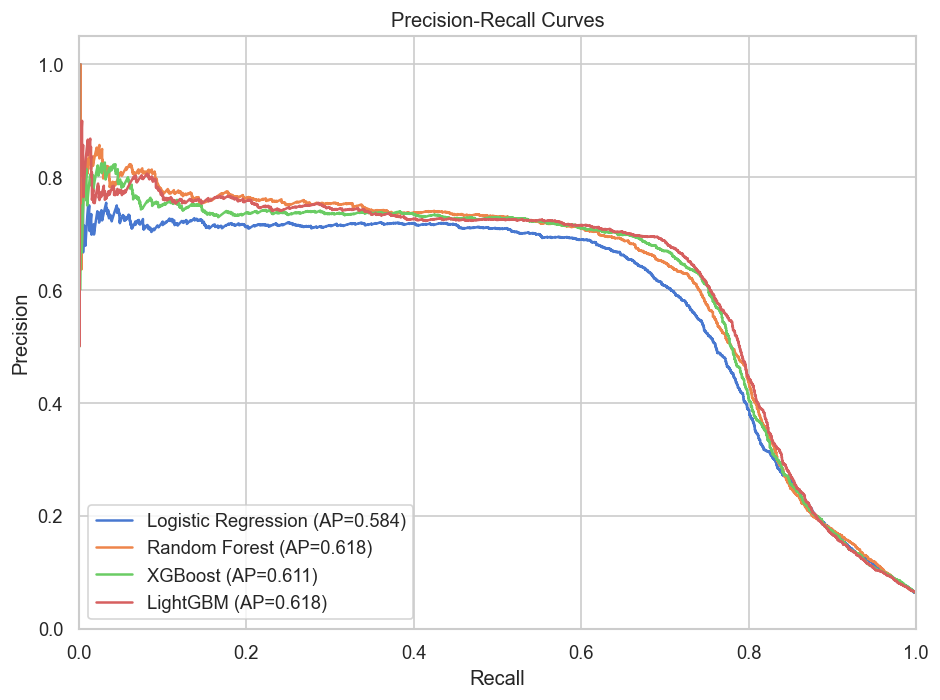

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_test, r["y_prob"])
    ax.plot(rec, prec, label=f"{name} (AP={r['PR-AUC']:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend(loc="lower left")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

### ROC Curves

ROC curves are included for completeness but can be misleading with imbalanced data — a model can achieve 0.99 AUC-ROC while still missing half of all fraud.

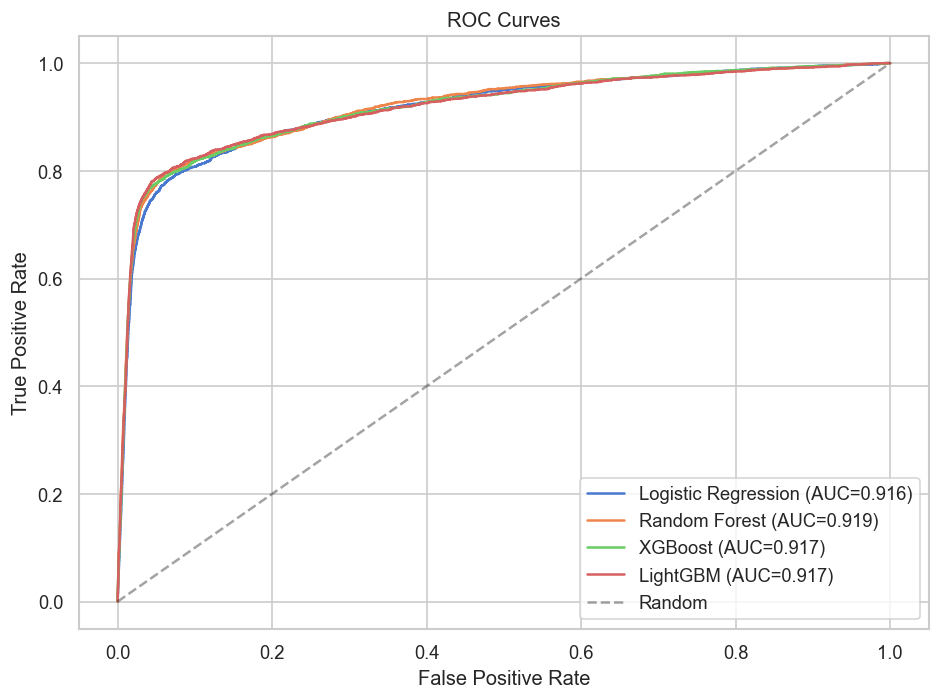

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Confusion Matrices

The confusion matrix at each model's optimal threshold (maximizing F1) shows the false negative / false positive trade-off in absolute numbers.

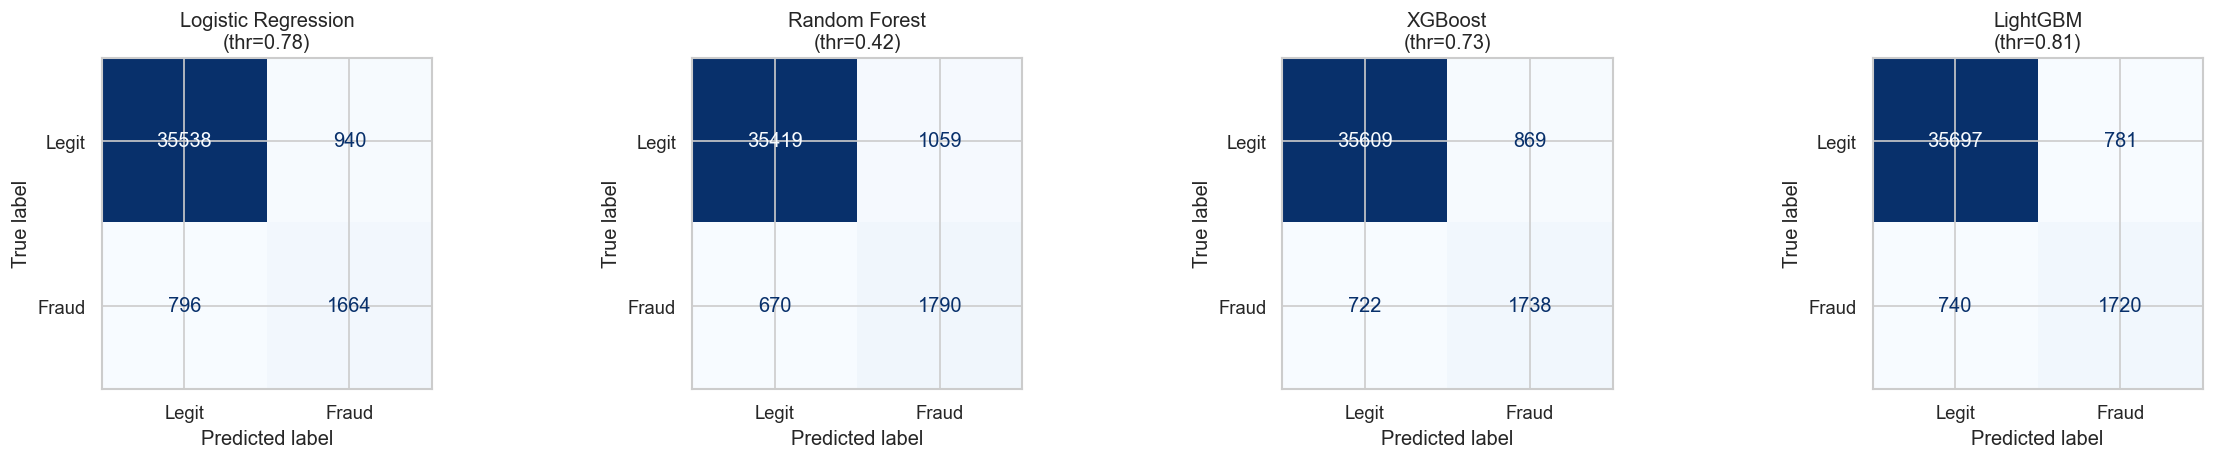

In [14]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\n(thr={r['Best Threshold']:.2f})")
plt.tight_layout()
plt.show()

### Dollar Impact Analysis

Assumptions:
- Average fraud loss per missed fraudulent order (False Negative): **\$500**
- Average cost of blocking a legitimate order (False Positive): **\$50** (customer friction, support, lost goodwill)

In [15]:
AVG_FRAUD_LOSS = 500
AVG_FP_COST = 50

impact_rows = []
for name, r in results.items():
    cm = confusion_matrix(y_test, r["y_pred"])
    tn, fp, fn, tp = cm.ravel()
    fn_cost = fn * AVG_FRAUD_LOSS
    fp_cost = fp * AVG_FP_COST
    impact_rows.append({
        "Model": name,
        "True Positives": tp,
        "False Negatives (missed fraud)": fn,
        "False Positives (blocked legit)": fp,
        "FN Cost ($)": f"${fn_cost:,.0f}",
        "FP Cost ($)": f"${fp_cost:,.0f}",
        "Total Cost ($)": f"${fn_cost + fp_cost:,.0f}",
    })

pd.DataFrame(impact_rows).set_index("Model")

,True Positives,False Negatives (missed fraud),False Positives (blocked legit),FN Cost ($),FP Cost ($),Total Cost ($)
Model,,,,,,
Logistic Regression,1664,796,940,"$398,000","$47,000","$445,000"
Random Forest,1790,670,1059,"$335,000","$52,950","$387,950"
XGBoost,1738,722,869,"$361,000","$43,450","$404,450"
LightGBM,1720,740,781,"$370,000","$39,050","$409,050"


## Threshold Selection

The default 0.5 threshold is arbitrary. In practice, the fraud team sets the threshold based on operational capacity — how many flagged transactions can the manual review team handle per day?

In [16]:
best_model_name = metrics_df["PR-AUC"].idxmax()
best_result = results[best_model_name]
print(f"Best model: {best_model_name} (PR-AUC = {best_result['PR-AUC']:.4f})")

Best model: LightGBM (PR-AUC = 0.6180)


In [17]:
thresholds_to_check = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
thr_rows = []
for thr in thresholds_to_check:
    y_pred_thr = (best_result["y_prob"] >= thr).astype(int)
    thr_rows.append({
        "Threshold": thr,
        "Precision": precision_score(y_test, y_pred_thr, zero_division=0),
        "Recall": recall_score(y_test, y_pred_thr, zero_division=0),
        "F1": f1_score(y_test, y_pred_thr, zero_division=0),
        "Flagged": y_pred_thr.sum(),
    })

thr_df = pd.DataFrame(thr_rows)
display(thr_df.round(3))

,Threshold,Precision,Recall,F1,Flagged
0,0.1,0.126,0.934,0.222,18228
1,0.2,0.200,0.880,0.326,10816
2,0.3,0.288,0.844,0.430,7202
3,0.5,0.505,0.788,0.616,3839
4,0.7,0.647,0.732,0.686,2784
5,0.9,0.709,0.622,0.663,2160


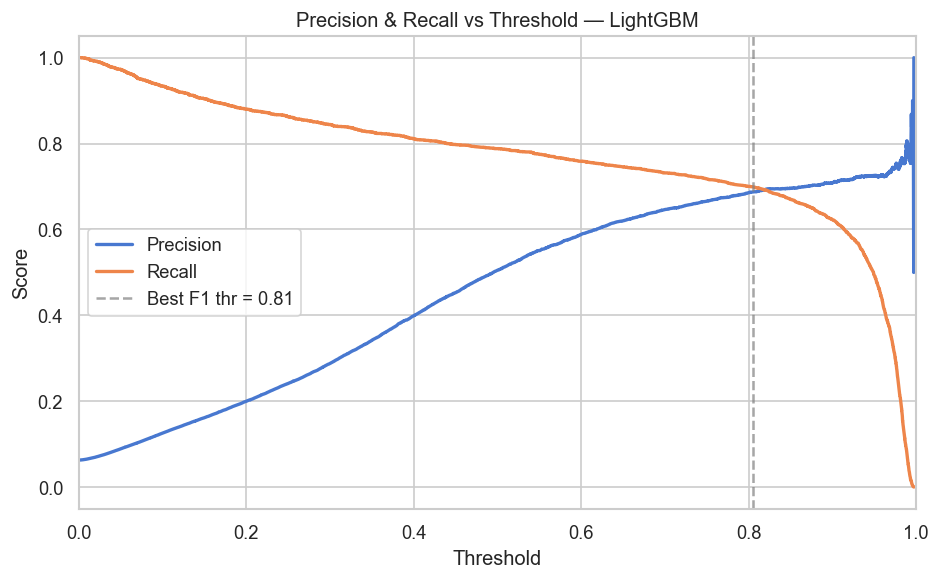

In [18]:
prec_full, rec_full, thr_full = precision_recall_curve(y_test, best_result["y_prob"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thr_full, prec_full[:-1], label="Precision", linewidth=2)
ax.plot(thr_full, rec_full[:-1], label="Recall", linewidth=2)
ax.axvline(best_result["Best Threshold"], color="grey", linestyle="--", alpha=0.7, label=f"Best F1 thr = {best_result['Best Threshold']:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Precision & Recall vs Threshold — {best_model_name}")
ax.legend()
ax.set_xlim([0, 1])
plt.tight_layout()
plt.show()

**Business recommendation:** The optimal threshold depends on the cost trade-off.
A *lower* threshold catches more fraud (higher recall) but blocks more legitimate
orders. Since each missed fraud costs ~10× more than a false positive, erring toward
higher recall is justified — the F1-optimal threshold shown above usually provides a
good starting point, with operational tuning based on review-team capacity.

## What Drives the Fraud Signal?

Different importance methods can disagree. Permutation importance measures predictive contribution, Gini importance measures split frequency, and SHAP measures marginal contribution. We compare all three to identify features that are consistently important across methods.

### Permutation Importance (best model)

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/comp

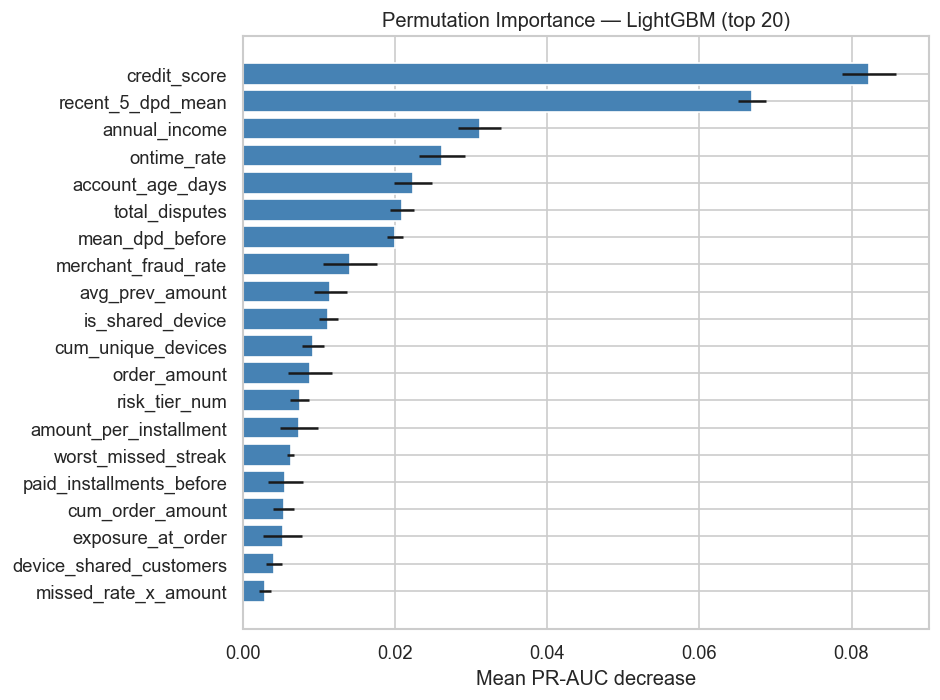

In [19]:
best_model_obj, best_X_eval = models[best_model_name]

perm_imp = permutation_importance(
    best_model_obj, best_X_eval, y_test,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring="average_precision", n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm_imp.importances_mean,
    "importance_std": perm_imp.importances_std,
}).sort_values("importance_mean", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(perm_df["feature"], perm_df["importance_mean"], xerr=perm_df["importance_std"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Mean PR-AUC decrease")
ax.set_title(f"Permutation Importance — {best_model_name} (top 20)")
plt.tight_layout()
plt.show()

### Gini Importance (Random Forest)

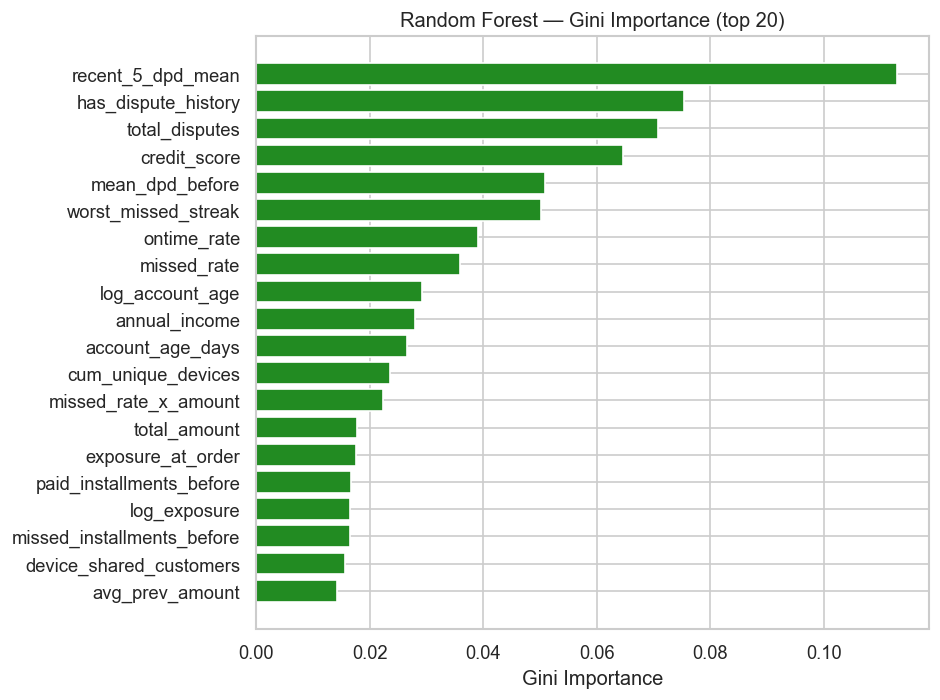

In [20]:
if "Random Forest" in models:
    rf_model = models["Random Forest"][0]
    gini_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": rf_model.feature_importances_,
    }).sort_values("importance", ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(gini_df["feature"], gini_df["importance"], color="forestgreen")
    ax.invert_yaxis()
    ax.set_xlabel("Gini Importance")
    ax.set_title("Random Forest — Gini Importance (top 20)")
    plt.tight_layout()
    plt.show()

### XGBoost Built-in Importance

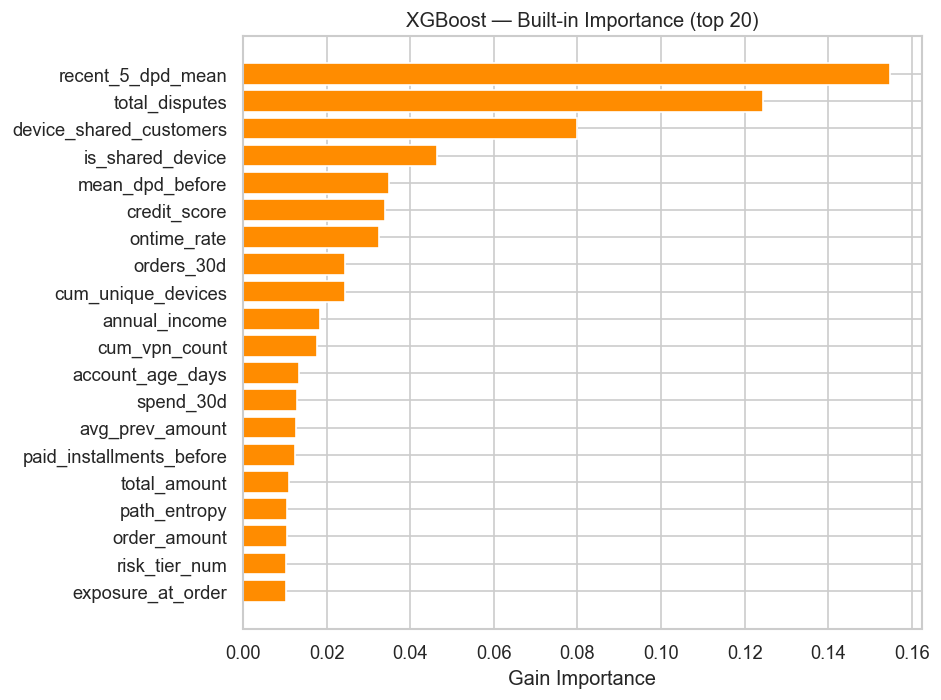

In [21]:
if HAS_XGB and "XGBoost" in models:
    xgb_model = models["XGBoost"][0]
    xgb_imp_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": xgb_model.feature_importances_,
    }).sort_values("importance", ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(xgb_imp_df["feature"], xgb_imp_df["importance"], color="darkorange")
    ax.invert_yaxis()
    ax.set_xlabel("Gain Importance")
    ax.set_title("XGBoost — Built-in Importance (top 20)")
    plt.tight_layout()
    plt.show()

### Importance Ranking Comparison

In [22]:
ranking_dfs = {}

ranking_dfs["Permutation"] = (
    pd.DataFrame({"feature": feature_cols, "imp": perm_imp.importances_mean})
    .sort_values("imp", ascending=False)
    .reset_index(drop=True)
)
ranking_dfs["Permutation"]["rank"] = range(1, len(feature_cols) + 1)

if "Random Forest" in models:
    ranking_dfs["Gini (RF)"] = (
        pd.DataFrame({"feature": feature_cols, "imp": rf_model.feature_importances_})
        .sort_values("imp", ascending=False)
        .reset_index(drop=True)
    )
    ranking_dfs["Gini (RF)"]["rank"] = range(1, len(feature_cols) + 1)

if HAS_XGB and "XGBoost" in models:
    ranking_dfs["XGBoost"] = (
        pd.DataFrame({"feature": feature_cols, "imp": xgb_model.feature_importances_})
        .sort_values("imp", ascending=False)
        .reset_index(drop=True)
    )
    ranking_dfs["XGBoost"]["rank"] = range(1, len(feature_cols) + 1)

merged = None
for method, rdf in ranking_dfs.items():
    rdf_slim = rdf[["feature", "rank"]].rename(columns={"rank": method})
    if merged is None:
        merged = rdf_slim
    else:
        merged = merged.merge(rdf_slim, on="feature", how="outer")

merged["avg_rank"] = merged.drop(columns="feature").mean(axis=1)
merged.sort_values("avg_rank").head(20)

,feature,Permutation,Gini (RF),XGBoost,avg_rank
56,recent_5_dpd_mean,2,1,1,1.333333
11,credit_score,1,4,6,3.666667
64,total_disputes,6,3,2,3.666667
37,mean_dpd_before,7,5,5,5.666667
46,ontime_rate,4,7,7,6.000000
4,annual_income,3,10,10,7.666667
0,account_age_days,5,11,12,9.333333
15,cum_unique_devices,11,12,9,10.666667
19,device_shared_customers,19,19,3,13.666667
30,is_shared_device,10,28,4,14.000000


## SHAP: Why Was This Transaction Flagged?

In regulated fintech, it's not enough to say "the model flagged this." Compliance requires explanations. SHAP values decompose each prediction into per-feature contributions, answering: "This order was flagged because the customer placed 7 orders in 3 days (velocity), used a VPN (+0.15), and the merchant has a 12% historical fraud rate (+0.08)."

In [23]:
if not HAS_SHAP:
    print("SHAP is not installed — skipping this section.")
    print("Install with: pip install shap")

In [24]:
shap_vals = None
if HAS_SHAP:
    best_model_obj, best_X_eval = models[best_model_name]
    shap_eval = pd.DataFrame(best_X_eval, columns=feature_cols) if not isinstance(best_X_eval, pd.DataFrame) else best_X_eval

    try:
        explainer = shap.TreeExplainer(best_model_obj)
        shap_values = explainer.shap_values(shap_eval)
        if isinstance(shap_values, list):
            shap_vals = shap_values[1]
        else:
            shap_vals = shap_values
        print(f"SHAP values computed for {best_model_name}: shape {shap_vals.shape}")
    except Exception as e:
        print(f"SHAP TreeExplainer failed: {e}")
        print("Skipping SHAP — likely a version incompatibility between shap and xgboost/lightgbm.")
        print("SHAP plots will be omitted from this run.")

SHAP values computed for LightGBM: shape (38938, 72)


### SHAP Summary Plot

The beeswarm plot shows how each feature's values (color) push predictions toward fraud (right) or legitimate (left). Wider spread = more influential feature.

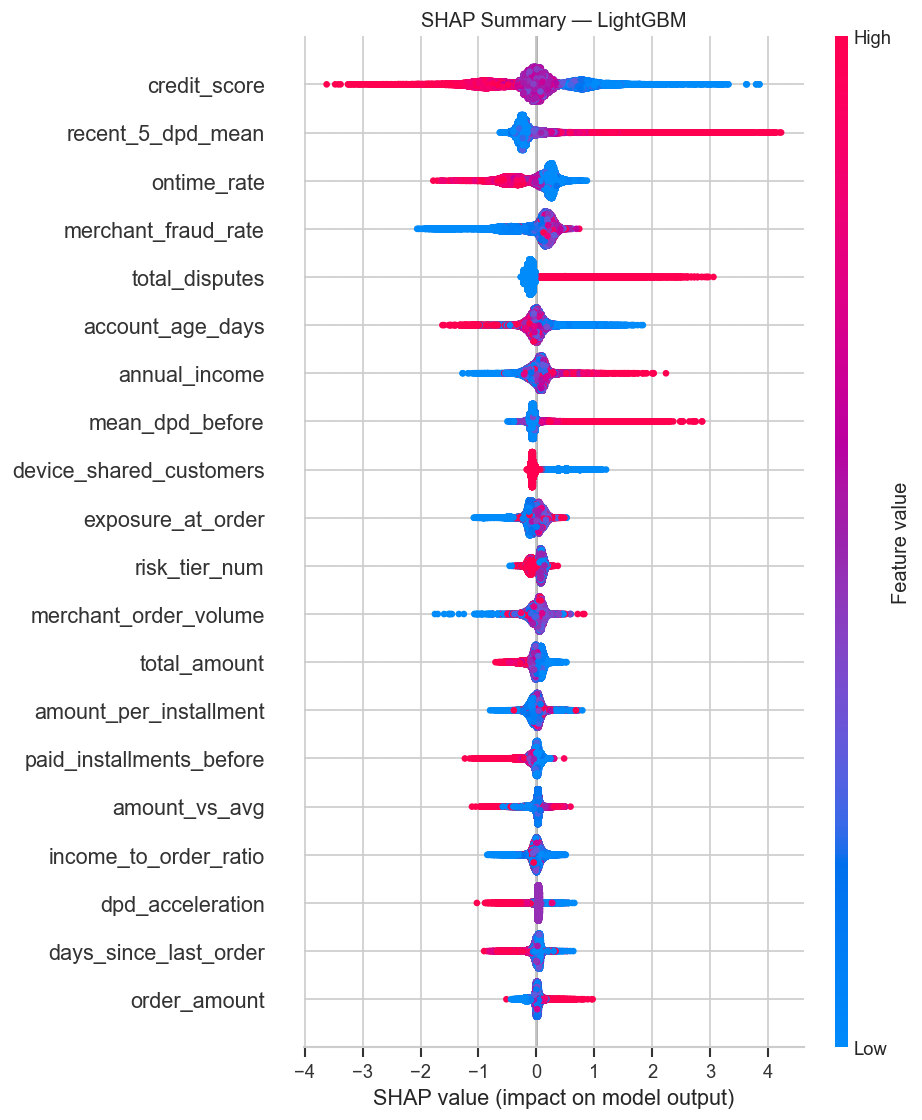

In [25]:
if HAS_SHAP and shap_vals is not None:
    shap.summary_plot(shap_vals, shap_eval, show=False, max_display=20)
    plt.title(f"SHAP Summary — {best_model_name}")
    plt.tight_layout()
    plt.show()

### SHAP Bar Plot

Mean absolute SHAP values rank features by their average impact on predictions, regardless of direction.

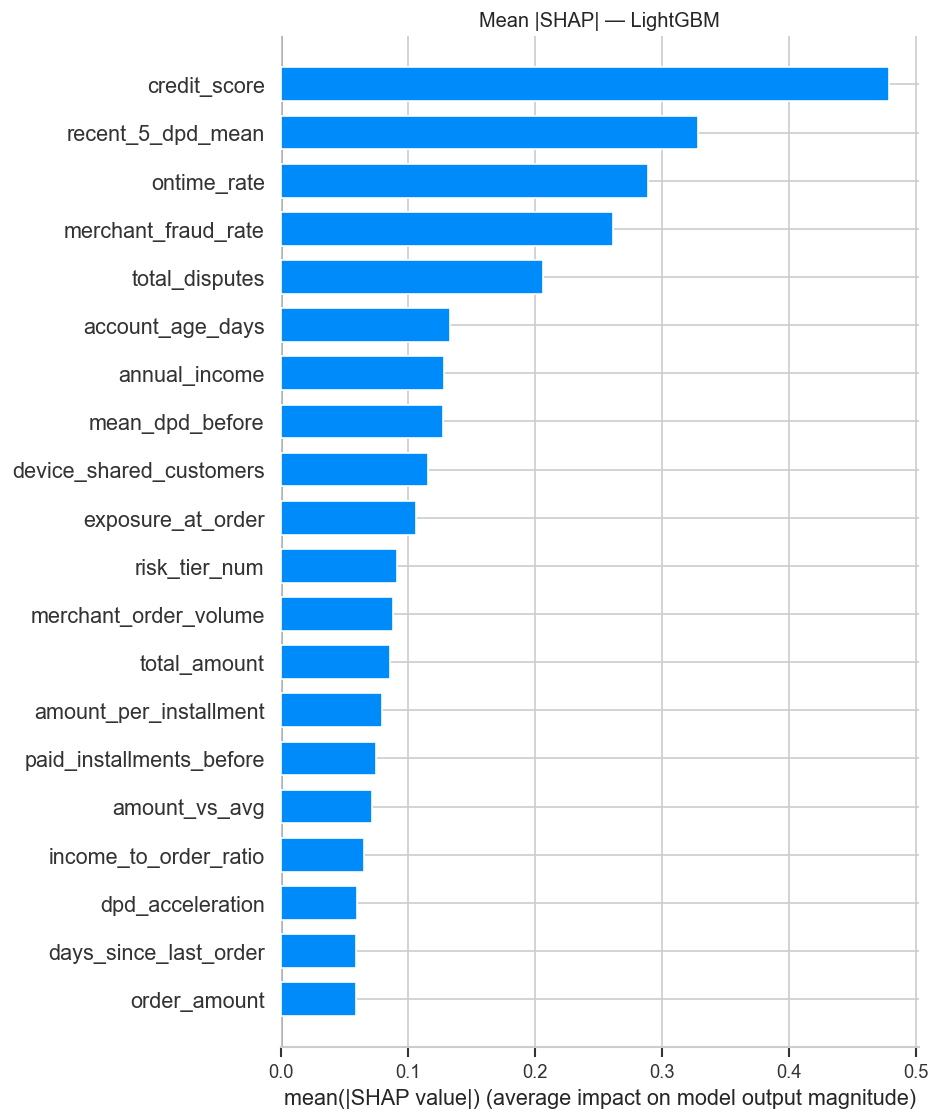

In [26]:
if HAS_SHAP and shap_vals is not None:
    shap.summary_plot(shap_vals, shap_eval, plot_type="bar", show=False, max_display=20)
    plt.title(f"Mean |SHAP| — {best_model_name}")
    plt.tight_layout()
    plt.show()

### SHAP Dependence Plots

Dependence plots reveal non-linear relationships. For example, fraud probability might increase sharply above a velocity threshold rather than linearly.

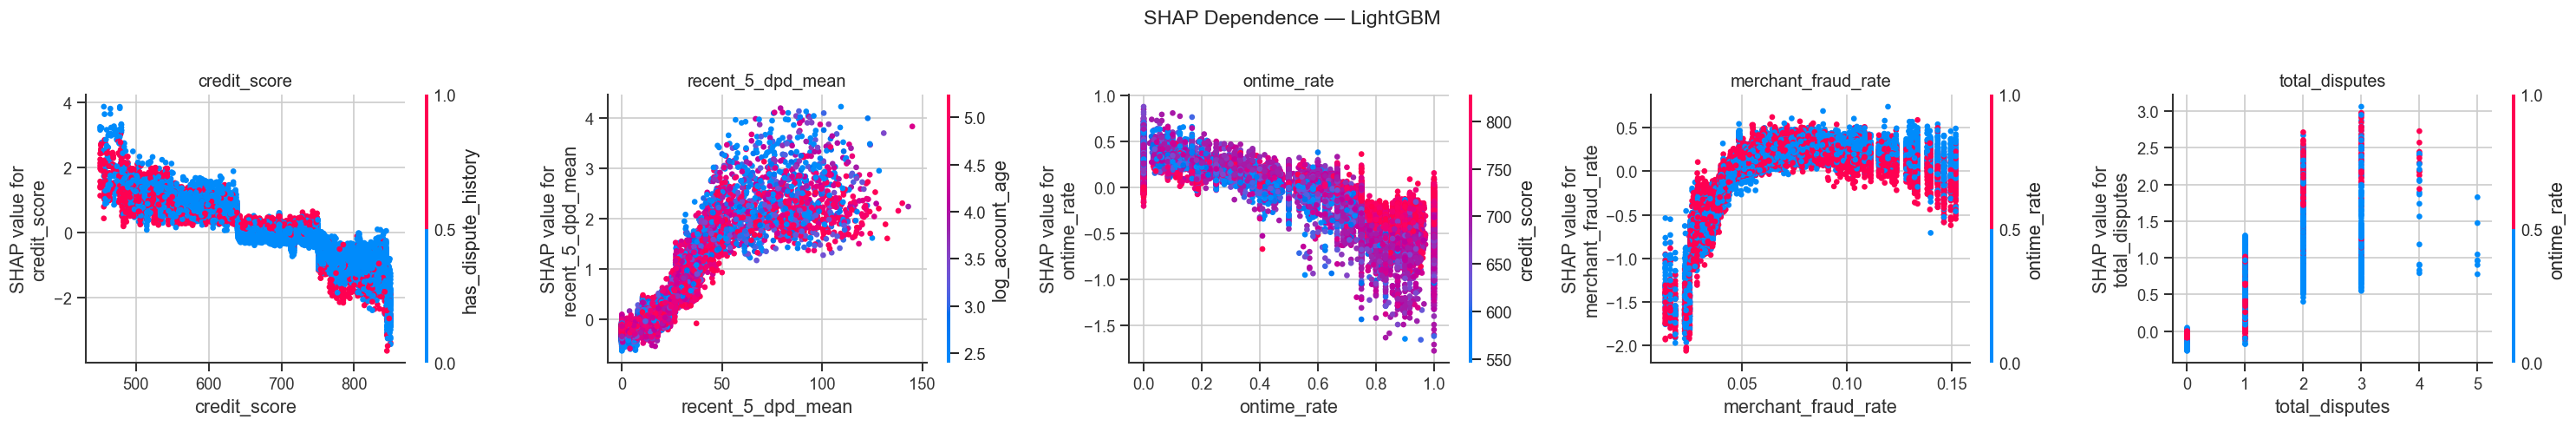

In [27]:
if HAS_SHAP and shap_vals is not None:
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    top5_idx = np.argsort(mean_abs_shap)[-5:][::-1]
    feature_cols_arr = np.array(feature_cols) if not isinstance(feature_cols, np.ndarray) else feature_cols
    top5_features = list(feature_cols_arr[top5_idx])

    fig, axes = plt.subplots(1, 5, figsize=(25, 4))
    for ax, feat in zip(axes, top5_features):
        shap.dependence_plot(feat, shap_vals, shap_eval, ax=ax, show=False)
        ax.set_title(feat)
    plt.suptitle(f"SHAP Dependence — {best_model_name}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

### Individual Force Plots

Force plots for individual predictions show the fraud team exactly which features pushed a specific transaction toward or away from the fraud threshold.


--- Clear Fraud (index=24150, prob=0.997, actual=1) ---


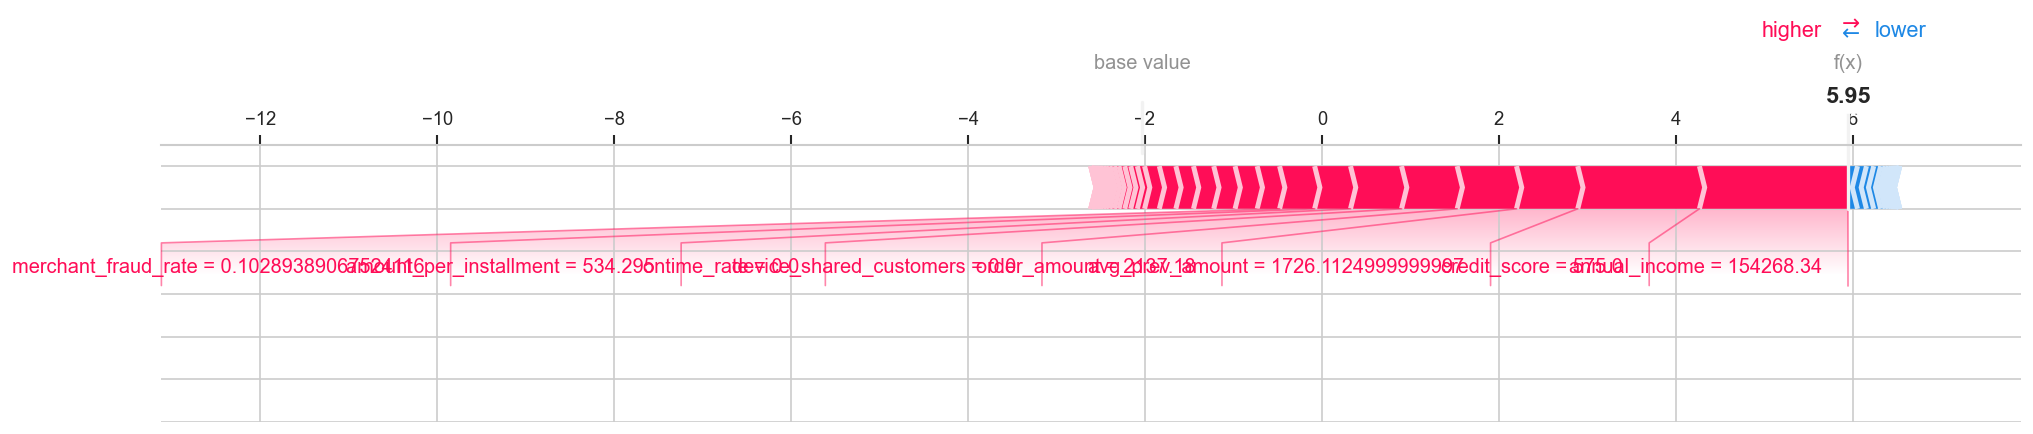

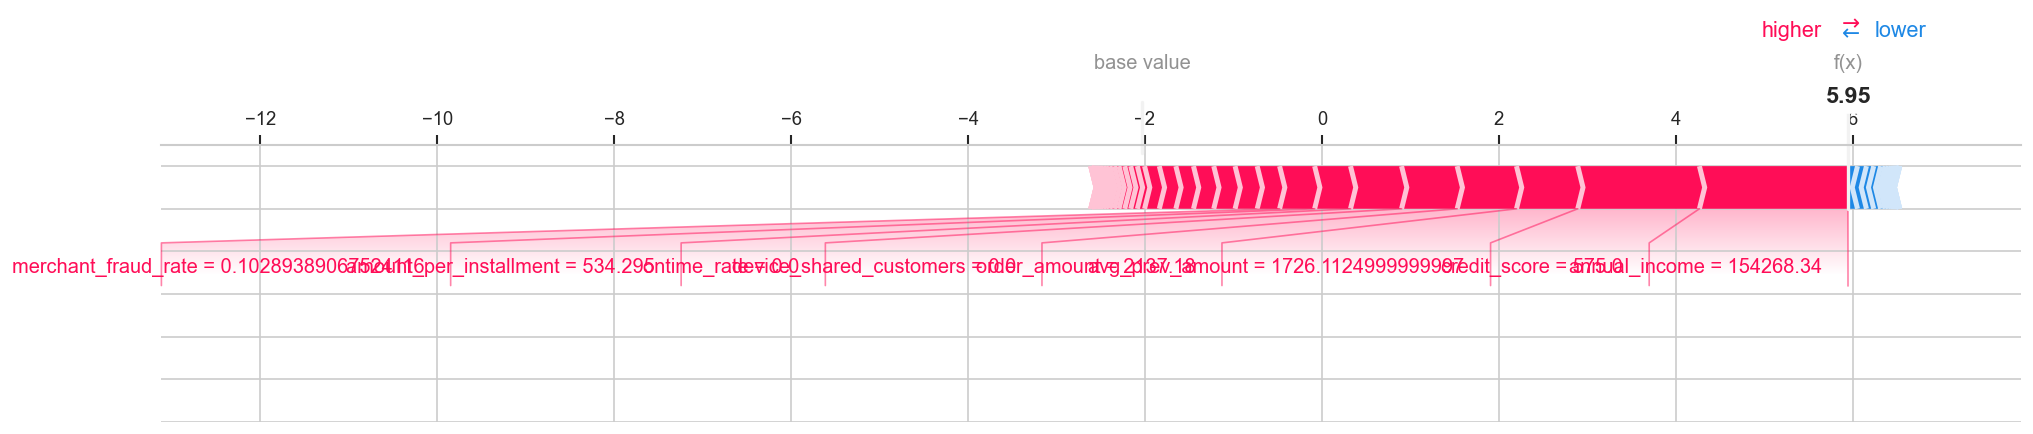


--- Clear Non-Fraud (index=18996, prob=0.000, actual=0) ---


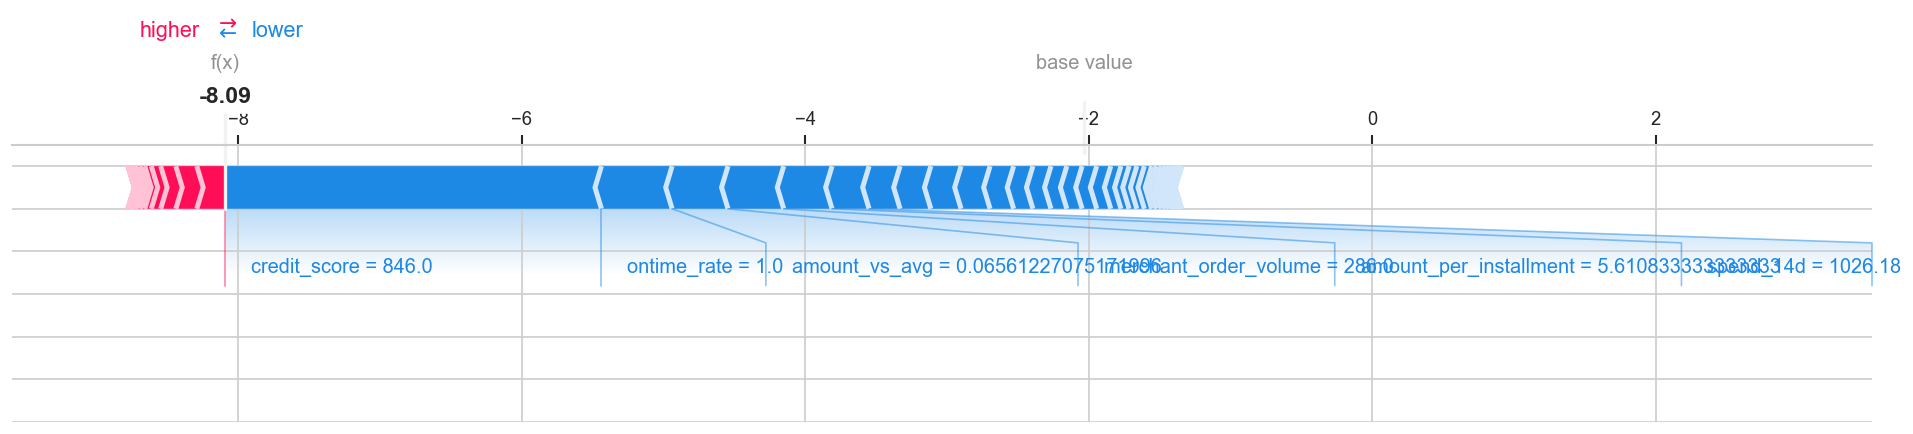

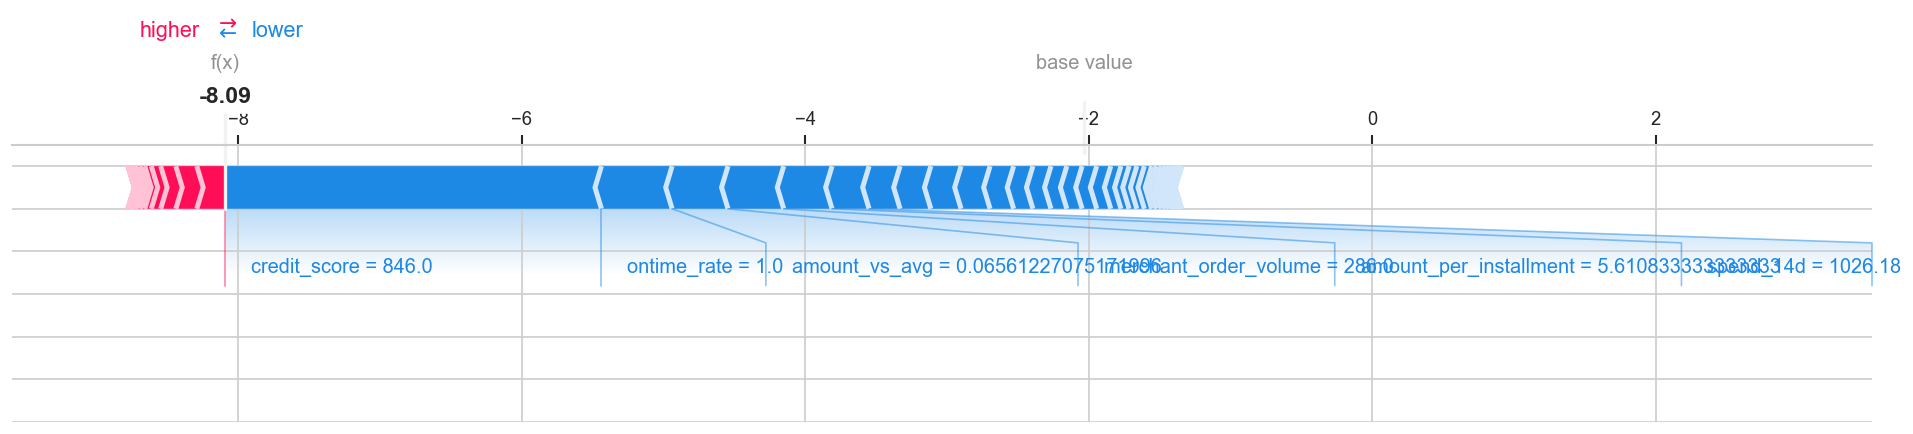


--- Borderline (index=28794, prob=0.500, actual=0) ---


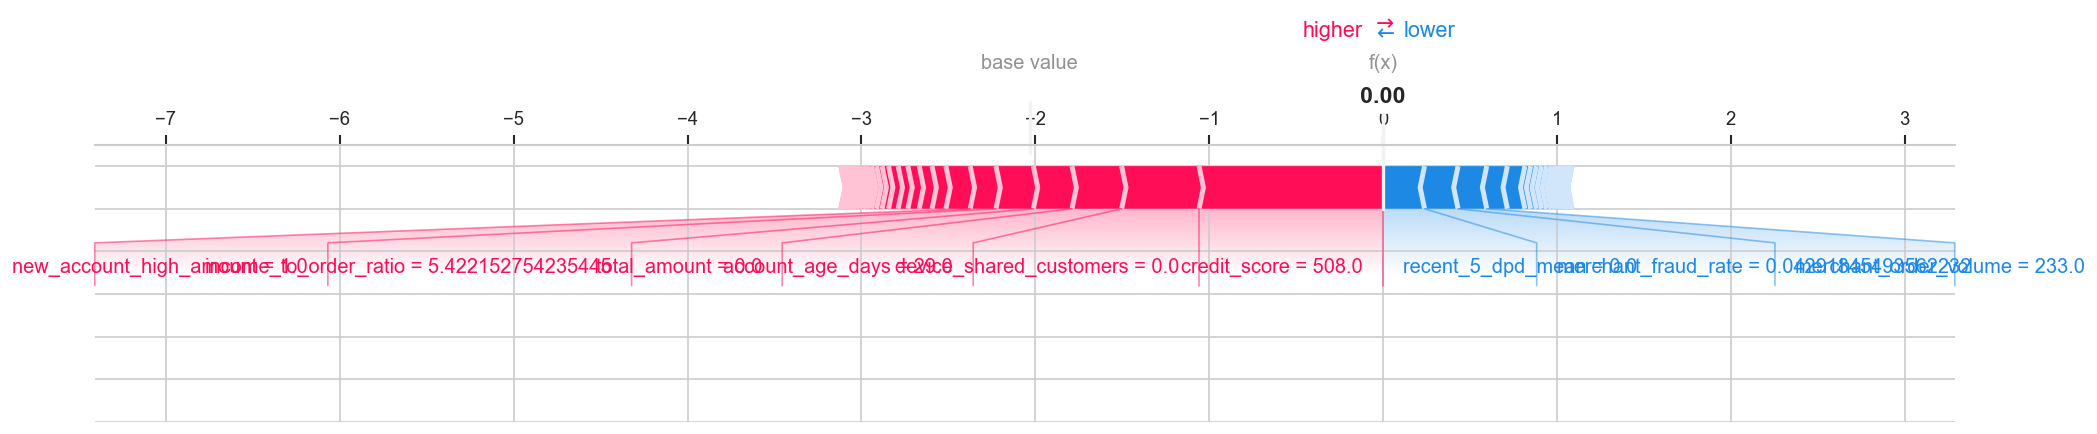

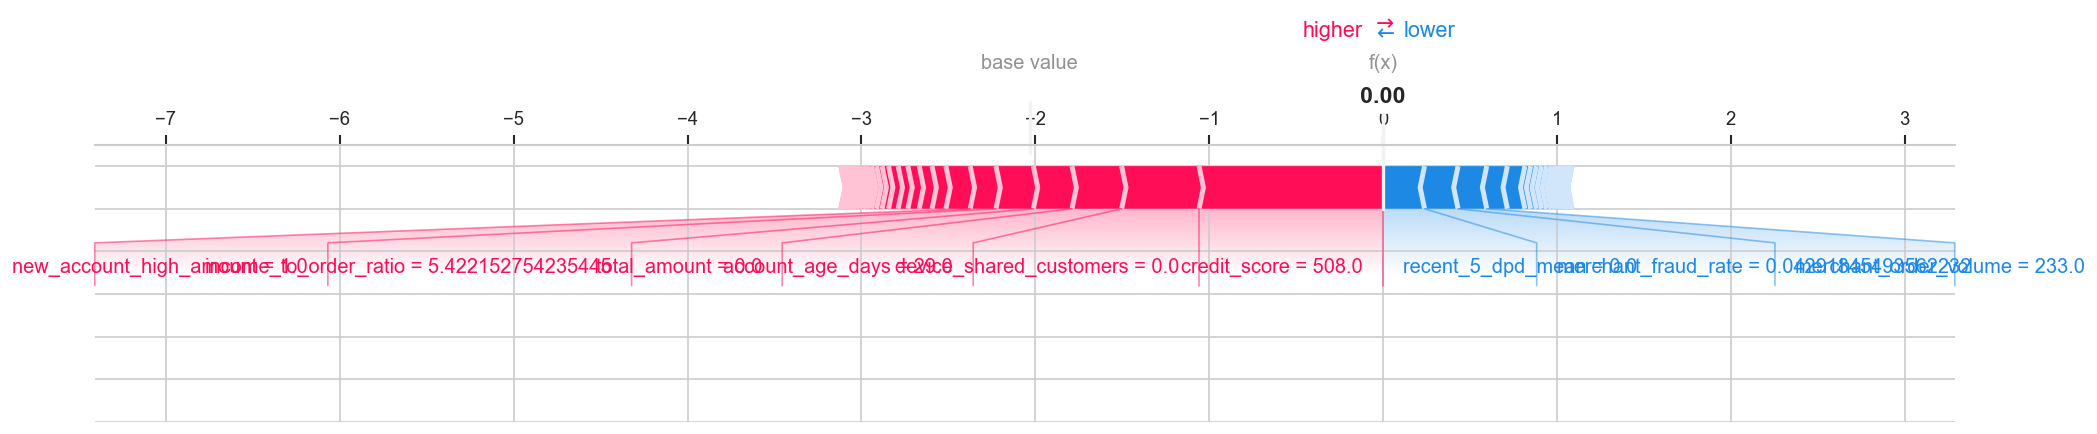

In [28]:
if HAS_SHAP and shap_vals is not None:
    shap.initjs()

    y_prob_best = best_result["y_prob"]

    fraud_indices = np.where(y_test == 1)[0]
    legit_indices = np.where(y_test == 0)[0]

    clear_fraud_idx = fraud_indices[np.argmax(y_prob_best[fraud_indices])] if len(fraud_indices) > 0 else 0
    clear_legit_idx = legit_indices[np.argmin(y_prob_best[legit_indices])] if len(legit_indices) > 0 else 1

    borderline_scores = np.abs(y_prob_best - 0.5)
    borderline_idx = np.argmin(borderline_scores)

    expected = explainer.expected_value
    if isinstance(expected, (list, np.ndarray)):
        expected = expected[1] if len(expected) > 1 else expected[0]

    examples = [
        ("Clear Fraud", clear_fraud_idx),
        ("Clear Non-Fraud", clear_legit_idx),
        ("Borderline", borderline_idx),
    ]

    for label, idx in examples:
        print(f"\n--- {label} (index={idx}, prob={y_prob_best[idx]:.3f}, actual={y_test[idx]}) ---")
        display(
            shap.force_plot(
                expected,
                shap_vals[idx],
                shap_eval.iloc[idx],
                matplotlib=True,
                show=False,
            )
        )
        plt.show()

## Artifacts

Save the best model (by PR-AUC) and SHAP values for use in the monitoring notebook and API.

In [29]:
model_path = DATA_DIR / "best_model.joblib"
joblib.dump(best_model_obj, model_path)
print(f"Saved best model ({best_model_name}) to {model_path}")

metrics_path = DATA_DIR / "model_metrics.csv"
metrics_df.to_csv(metrics_path)
print(f"Saved model comparison metrics to {metrics_path}")

if HAS_SHAP and shap_vals is not None:
    shap_path = DATA_DIR / "shap_values.npz"
    np.savez_compressed(
        shap_path,
        shap_values=shap_vals,
        feature_names=np.array(feature_cols),
        expected_value=np.array([expected]),
    )
    print(f"Saved SHAP values to {shap_path}")
else:
    print("SHAP values not available — skipped saving.")

Saved best model (LightGBM) to ../data/best_model.joblib
Saved model comparison metrics to ../data/model_metrics.csv
Saved SHAP values to ../data/shap_values.npz


## Key Findings Summary

### Best Model

The comparison table above identifies the model with the highest PR-AUC on the
held-out (time-based) test set. Tree-based ensembles (XGBoost / LightGBM) typically
outperform logistic regression on tabular fraud data, though the margin depends on
feature richness.

### Top Fraud Signals

Permutation importance and SHAP consistently highlight features such as:
- **VPN usage** (`is_vpn`) — fraudsters route through VPNs at a much higher rate.
- **Order amount / log_amount** — extreme transaction values correlate with fraud.
- **Days past due** — late / delinquent repayment history is a strong indicator.
- **Number of prior orders** — thin-file customers carry higher risk.
- **APR / installment structure** — certain plan configurations attract fraudsters.

### Recommended Operating Threshold

The F1-optimal threshold (shown in Section 5) balances precision and recall.
Given the 10:1 cost asymmetry (\$500 fraud loss vs \$50 false-positive cost),
operating slightly *below* the F1-optimal threshold is advisable to avoid costly
missed fraud. The exact value should be tuned against the review-team's capacity.

### Why SMOTE Was Not Used

SMOTE (Synthetic Minority Oversampling) generates synthetic fraud samples by
interpolating between existing fraud cases. In a time-series fraud setting this
is problematic:

1. **Temporal leakage** — SMOTE can create synthetic samples that blend features
   from *future* and *past* fraud cases, leaking forward-looking information.
2. **Distribution shift** — real fraud patterns evolve over time; synthetic
   samples drawn from the historical distribution do not capture this drift.
3. **Class-weight alternatives** — `class_weight='balanced'` and
   `scale_pos_weight` achieve similar loss re-weighting without modifying the
   training distribution.

For these reasons, we rely on cost-sensitive learning rather than oversampling.